**VERSION v6**: Uses new signal and satellite catalog and also the new corrected satbeam file (without null satellites and with slightly corrected telescope beam response maps).

### 1. Initialization

Imports and general parameters (from *parameters.py*).

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import satellite_RFI.src.simulation_NC as sim
from scipy.optimize import lsq_linear, nnls
import sys
sys.path.insert(0, './initialization/')
from imports import *
import parameters as pm


In [3]:
## ----- FITTING PARAMETERS ----- ##

# folder and name of final results file
folder = "results/v6_results/"

# cost function from eq. 11 (options: "C1"=radiometer, "C2"=1)
CF = "C2"

# angular mask [degrees] (options: 1,5 or None)
deg = None
if deg!=None:  times_nearby  = pickle.load(open(pm.path_nearby, "rb"))[deg]
else:  times_nearby = None

# thermal mask [kelvin] (options: 25,50,100 or None)
temp = None

# threshold pixel mask (options: 2,5,7 or None)
pix = None

# temporal mask [seconds] (options: 775-1000, 2200-2400, 5500-6200 or None)
time_slice = (None,None)


In [4]:
pm.show_parameters(CF, deg, temp, pix, time_slice)
print()
fname = pm.my_name(folder, CF, deg, temp, pix, time_slice)
print("File with final alpha parameters will be '{}'".format(fname))


Block: 1551055211
Frequency range: 1100 - 1350 MHz
Time range: inf - inf seconds
The cost function denominator will be: unweighted (C2).
Masking: None

File with final alpha parameters will be 'results/v6_results/nomask_C2.p'


### 2. Setting up the simulation

We initialize the SatelliteSimulation object, which will store the information. 

Getting catalog...
 - Number of signals in satellite catalog: 248 (initial), 131 (final).
Getting beam response...
 - Number of satellites present: 60
 - Size of sat_beam: 1.181 GB
Getting temperature factors for each signal...
 - Length of Tb_factors: 131
 - Size of Tb_factors: 0.001 GB
Getting observational data...
 - Size of observational data: 0.020 GB
 - Shape of observational data: (1199, 2204)
Masking...


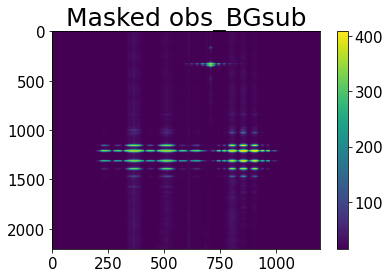

In [5]:
# initializing the simulation
sat = sim.SatelliteSimulation(
    survey_info=[pm.nd_s0, pm.frequency],
    path_catalog=pm.path_catalog,
    path_beam=pm.path_beam,
    freq_range=pm.freq_range,
    freq_slice=pm.freq_slice,
    time_slice=time_slice,
    verbose=True,
)

# getting observations
sat.use_observations(path_observations=pm.path_observations, verbose=True)

# applying mask
print("Masking...")
sat.use_mask(times_nearby, temp, pix, verbose=True)


In [6]:
# defining the cost function (only for testing, this won't be used in the optimization)
if CF=="C1":
    def Cost_Function(alphas):
        ''' Computes CF for the given alphas, with weights=obs (case C1). '''
        sat.simulate(alphas)
        CF = np.sum( ((sat.obs_BGsub-sat.sim) / sat.obs)**2 )
        print(CF,end="\t")
        return CF
elif CF=="C2":
    def Cost_Function(alphas):
        ''' Computes CF for the given alphas, with weights=1 (case C2). '''
        sat.simulate(alphas)
        CF = np.sum( (sat.obs_BGsub-sat.sim)**2 )
        print(CF,end="\t")
        return CF

# defining initial values (only for testing, this won't be used in the optimization)
alphas0 = np.zeros(len(sat.catalog))
_ = Cost_Function(alphas0)


3090395767.6826134	

### 3. Running the optimization

#### A. Getting values

We now run the optimization with the functions and parameters defined above. This part of the code **needs approximately 15GB** of memory to run the `nnls` optimization, and it takes some minutes to run the code for the creation of matrixes A and b.

In [7]:
def optimization_setup(CF, verbose=True):  
    ''' Computes the necessary matrices A,b,Anorm for the nnls minimization. '''

    # in each satellite, loop through the specific signals
    A = np.empty((sat.obs_BGsub.size, len(sat.catalog)))
    if verbose:  print("Creating matrix A and b ...")
    for i_sat, start in enumerate(sat.index_sats):
        stop = start + sat.n_signals[i_sat]
        for i in range(start, stop):
            A[:, i] = (sat.sat_beam[i_sat] * sat.Tb_factors[i][:,None]).ravel()
    b = sat.obs_BGsub.ravel()

    # checking dimensions
    if verbose: 
        print(f" - Size of matrix A: {A.nbytes / 1024**3:.3f} GB")
        print(f" - Size of vector b: {b.nbytes / 1024**3:.3f} GB")

    # defining weights if necessary
    if verbose:  print("Applying weights...")
    if CF=="C1":  
        weights = 1.0 / sat.obs.ravel()
        A *= weights[:,None]
        b *= weights

    # normalizing for faster fitting
    if verbose:  print("Normalizing...")
    Anorm = np.linalg.norm(A, axis=0)
    Anorm[Anorm==0] = 1
    A /= Anorm
    
    return A,b,Anorm


In [8]:
# setting up the optimization (creating matrixes A,b)
A,b,Anorm = optimization_setup(CF)


Creating matrix A and b ...
 - Size of matrix A: 2.579 GB
 - Size of vector b: 0.020 GB
Applying weights...
Normalizing...


In [9]:
# running the optimization
start = time.perf_counter()
print("Running optimization...")
x,rnorm = nnls(A, b, maxiter=1000)
print("Done.")
elapsed = time.perf_counter() - start
print(f"This took {elapsed:.2f} seconds, or {elapsed/60:.2f} minutes".format())


Running optimization...
Done.
This took 43.47 seconds, or 0.72 minutes


#### B. Plotting best-fit

In [10]:
# saving best fit values
alphas_BF = x / Anorm

# simulating
sat = sim.SatelliteSimulation(
    survey_info=[pm.nd_s0, pm.frequency],
    path_catalog=pm.path_catalog,
    path_beam=pm.path_beam,
    freq_range=pm.freq_range,
    freq_slice=pm.freq_slice,
    time_slice=time_slice,
    verbose=False,
)

# getting observations, mask and using alphas
sat.use_observations(path_observations=pm.path_observations, verbose=False)
sat.use_mask(times_nearby, temp, pix, verbose=False)
sat.simulate(alphas_BF)


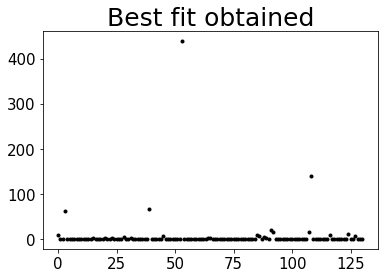

2215995532.1995335	

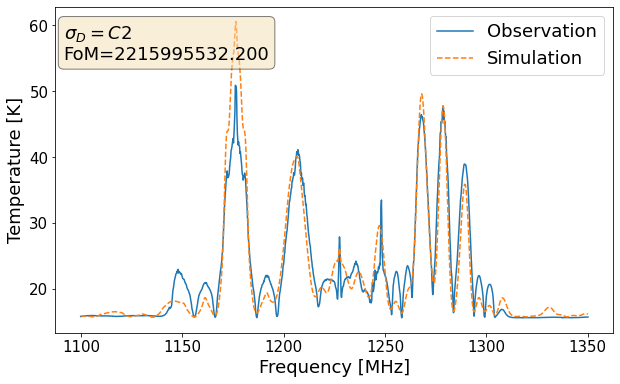

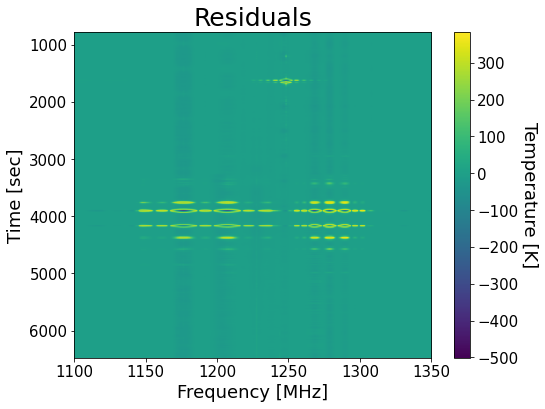

In [11]:
# plotting values
plt.plot(alphas_BF,"k.")
plt.title("Best fit obtained")
plt.show()

# plotting simulation
f = sat.frequency[sat.ifreq[0]:sat.ifreq[1]]
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(f, np.ma.mean(sat.obs_BGsub.T + sat.BG.T, axis=0), label='Observation')
ax.plot(f, np.ma.mean(sat.sim.T + sat.BG.T, axis=0), '--', label='Simulation')
textstr = f"$\\sigma_D={CF}$\nFoM={Cost_Function(alphas_BF):.3f}"
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.015, 0.95, textstr, transform=ax.transAxes, fontsize=18, verticalalignment='top', bbox=props)
ax.set_xlabel('Frequency [MHz]')
ax.set_ylabel('Temperature [K]')
ax.legend(loc='upper right')
plt.show()

# plotting simulation
t = sat.time[sat.itime[0]:sat.itime[1]]
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.imshow(sat.obs_BGsub.T - sat.sim.T, aspect='auto', extent=[f[0], f[-1], t[-1], t[0]])
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label(r'Temperature [K]', rotation=270, labelpad=20)
ax.set_ylabel('Time [sec]')
ax.set_xlabel('Frequency [MHz]')
ax.set_title("Residuals")
plt.show()


In [12]:
# saving information in the file
data_info = {
    "initial" : alphas0,
    "CF" : CF,
    "mask_degree" : deg, 
    "mask_temperature" : temp, 
    "mask_pix" : pix, 
    "time_slice" : time_slice,
    "frequency_slice" : pm.freq_slice, 
    "best-fit" : alphas_BF,
}

print(f"Information saved in file '{fname}'.")
pickle.dump( data_info, open(fname,"wb") )


Information saved in file 'results/v6_results/nomask_C2.p'.
